# HW#2-4

아래와 같은 영상에 대하여 45°, -45° 방향의 대각선 edge를 검출하되, Sobel 연산자를 변형하여 적절한 마스크를 만들어 적용해 보세요

Image shape: (1200, 1600), dtype: uint8


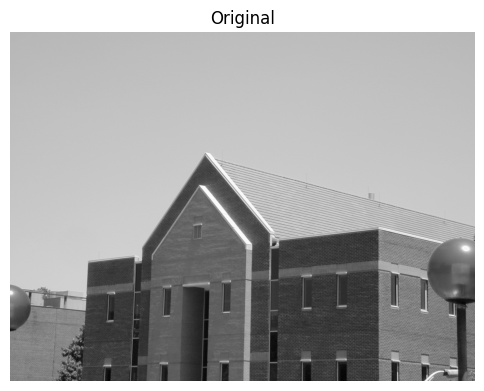

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 영상 로드 (grayscale)
img = cv2.imread('data/school.jpg', cv2.IMREAD_GRAYSCALE)
print(f'Image shape: {img.shape}, dtype: {img.dtype}')

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.show()

## 대각선 Sobel 마스크 설계

표준 Sobel 연산자는 수평/수직 방향의 edge를 검출한다:  
- Gx (수직 edge): `[[-1,0,1],[-2,0,2],[-1,0,1]]`  
- Gy (수평 edge): `[[-1,-2,-1],[0,0,0],[1,2,1]]`  

이를 45° 회전시키면 대각선 edge 검출 마스크를 얻을 수 있다:  
- **+45° 방향 edge** (↗ 방향 gradient): `[[ 0, 1, 2],[-1, 0, 1],[-2,-1, 0]]`  
- **-45° 방향 edge** (↘ 방향 gradient): `[[-2,-1, 0],[-1, 0, 1],[ 0, 1, 2]]`

In [2]:
# 대각선 Sobel 마스크 정의
# +45° 방향 edge 검출 마스크
sobel_45 = np.array([[ 0,  1,  2],
                     [-1,  0,  1],
                     [-2, -1,  0]], dtype=np.float64)

# -45° 방향 edge 검출 마스크
sobel_n45 = np.array([[-2, -1,  0],
                      [-1,  0,  1],
                      [ 0,  1,  2]], dtype=np.float64)

print('+45° mask:')
print(sobel_45)
print()
print('-45° mask:')
print(sobel_n45)

+45° mask:
[[ 0.  1.  2.]
 [-1.  0.  1.]
 [-2. -1.  0.]]

-45° mask:
[[-2. -1.  0.]
 [-1.  0.  1.]
 [ 0.  1.  2.]]


In [3]:
# 컨볼루션 적용
img_float = img.astype(np.float64)

# filter2D로 컨볼루션 (ddepth=-1은 입력과 같은 depth, CV_64F로 음수값 보존)
edge_45 = cv2.filter2D(img_float, cv2.CV_64F, sobel_45)
edge_n45 = cv2.filter2D(img_float, cv2.CV_64F, sobel_n45)

# 절대값 취해서 시각화용으로 변환
edge_45_abs = np.abs(edge_45)
edge_n45_abs = np.abs(edge_n45)

# 두 대각선 edge 합성 (magnitude)
edge_combined = np.sqrt(edge_45**2 + edge_n45**2)

# 0~255로 정규화
def normalize_to_uint8(img):
    return np.clip(img / img.max() * 255, 0, 255).astype(np.uint8)

edge_45_vis = normalize_to_uint8(edge_45_abs)
edge_n45_vis = normalize_to_uint8(edge_n45_abs)
edge_combined_vis = normalize_to_uint8(edge_combined)

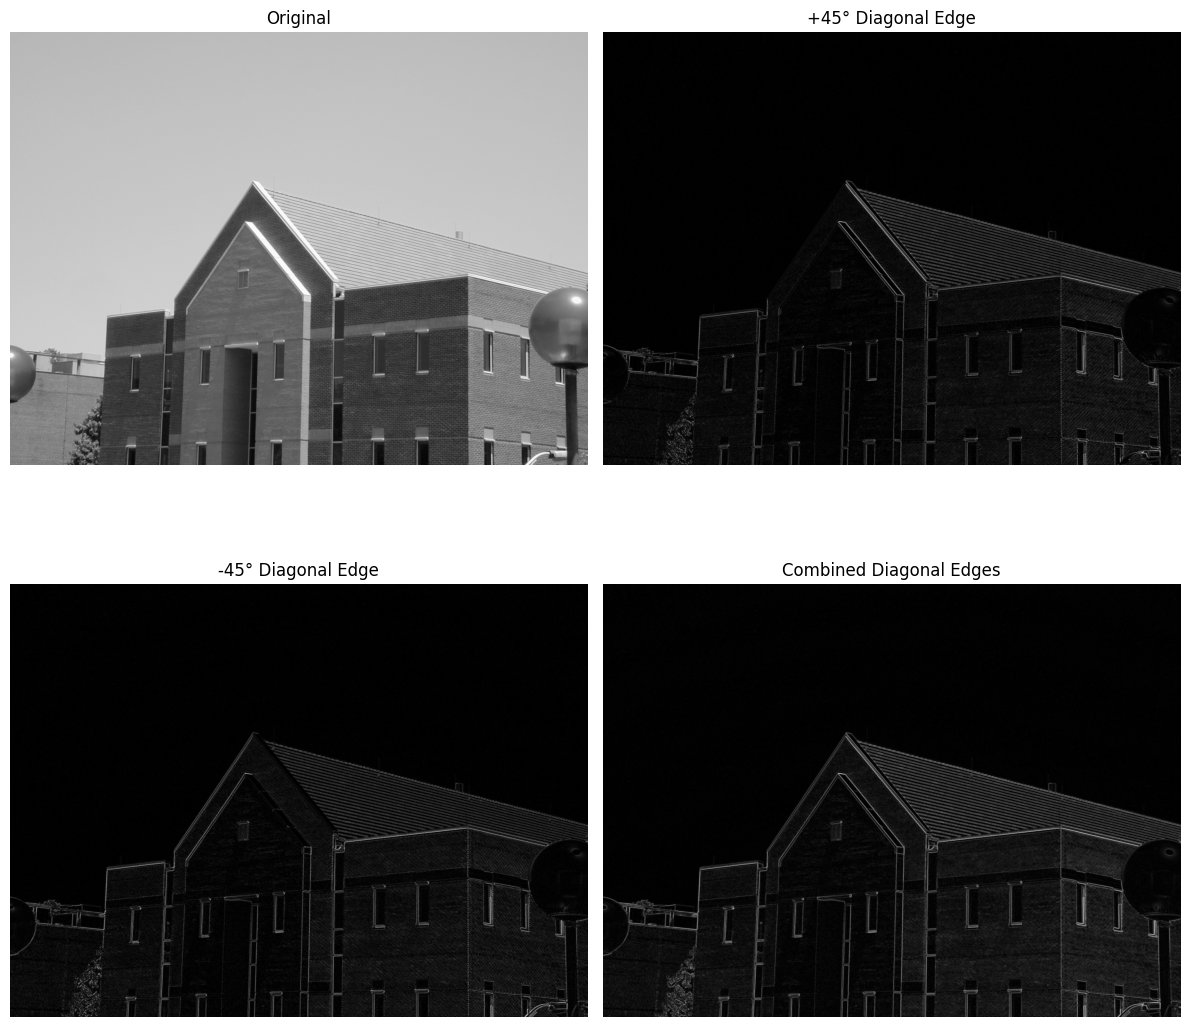

In [4]:
# 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(edge_45_vis, cmap='gray')
axes[0, 1].set_title('+45° Diagonal Edge')
axes[0, 1].axis('off')

axes[1, 0].imshow(edge_n45_vis, cmap='gray')
axes[1, 0].set_title('-45° Diagonal Edge')
axes[1, 0].axis('off')

axes[1, 1].imshow(edge_combined_vis, cmap='gray')
axes[1, 1].set_title('Combined Diagonal Edges')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('result/hw2_4_result.png', dpi=150, bbox_inches='tight')
plt.show()

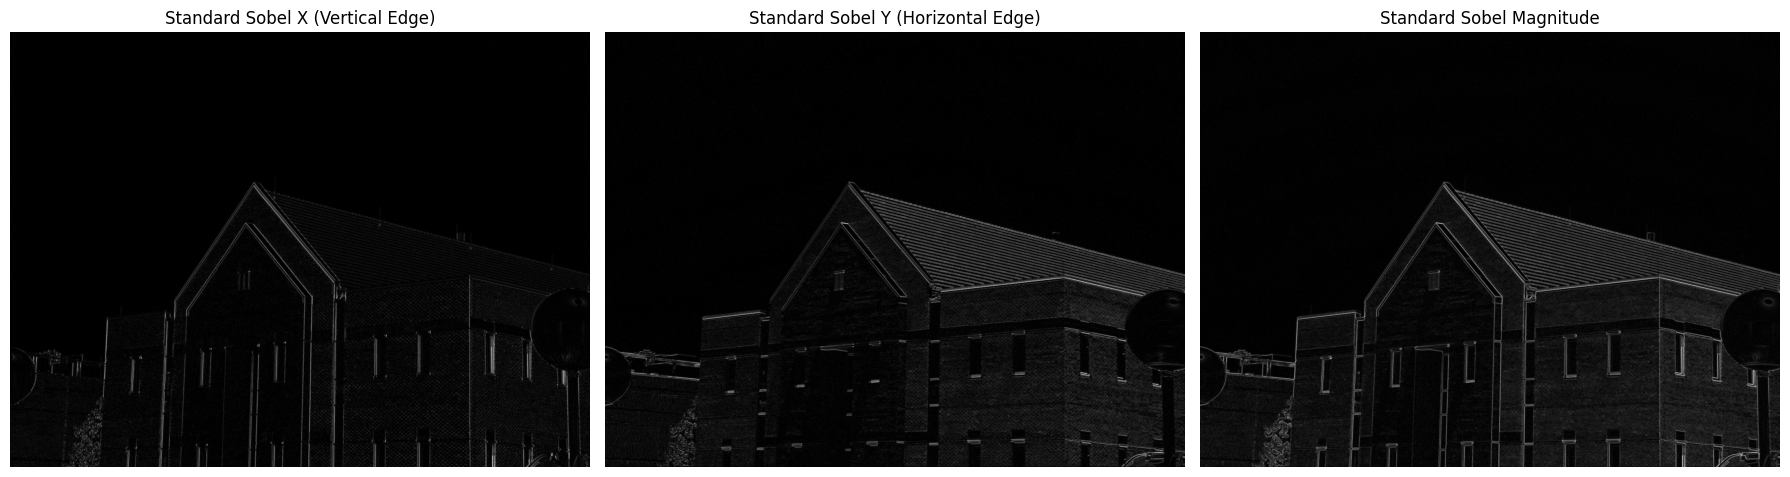

In [5]:
# 표준 Sobel (수평/수직)과 비교
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(normalize_to_uint8(np.abs(sobel_x)), cmap='gray')
axes[0].set_title('Standard Sobel X (Vertical Edge)')
axes[0].axis('off')

axes[1].imshow(normalize_to_uint8(np.abs(sobel_y)), cmap='gray')
axes[1].set_title('Standard Sobel Y (Horizontal Edge)')
axes[1].axis('off')

axes[2].imshow(normalize_to_uint8(sobel_mag), cmap='gray')
axes[2].set_title('Standard Sobel Magnitude')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('result/hw2_4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 결과 분석

**마스크 설계 원리:**  
표준 Sobel 연산자(Gx, Gy)를 45° 회전시켜 대각선 방향의 gradient를 검출하도록 변형하였다. 마스크의 가중치 배치(2, 1)는 Sobel의 smoothing + differentiation 특성을 그대로 유지한다.

**+45° 마스크 결과:**  
좌하→우상 방향(↗)의 intensity 변화가 큰 edge가 강조된다. 건물 지붕의 삼각형 윤곽선 중 해당 방향 성분이 잘 검출된다.

**-45° 마스크 결과:**  
좌상→우하 방향(↘)의 edge가 강조된다. +45°와 상보적인 대각선 성분을 검출한다.

**Combined 결과:**  
두 대각선 edge를 합성하면 모든 대각선 방향의 edge를 포함하며, 표준 Sobel(수평+수직)과 비교 시 대각선 구조물(지붕 경사면 등)이 더 뚜렷하게 나타난다.